# REZ annual wind drought time series, ERA5 vs BARRA-RE2

This notebook updates the original REZ annual time-series notebook by adding BARRA-RE2 comparison.

Main additions:

- ERA5 annual REZ statistics are calculated from yearly binary wind-drought mask files.
- BARRA-RE2 annual REZ statistics are calculated from the previously generated BARRA-RE2 annual ensemble-mean drought-days file.
- BARRA-RE2 has 22 realizations, already averaged into one annual ensemble-mean drought-days field before comparison.
- The REZ mask is matched onto each grid.
- Final plots compare ERA5 and BARRA-RE2 over 1990 to 2025.


In [1]:
import os
from glob import glob

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# =====================
# Paths
# =====================
# ERA5 yearly binary wind-drought masks
wd_dir_era5 = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"

# REZ mask on ERA5 grid
rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"

# BARRA-RE2 annual drought-days file calculated previously
# This file should contain annual_wind_drought_days_ensemble_mean with dimensions year, lon, lat
barra_annual_file = (
    "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/"
    "frequency_analysis/"
    "BARRA_RE2_P20_3day_annual_wind_drought_days_ensemble_mean_1990_2025.nc"
)

# Output folder
output_dir = (
    "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/"
    "frequency_analysis/rez_timeseries_comparison"
)
os.makedirs(output_dir, exist_ok=True)

start_year = 1990
end_year = 2025

print("ERA5 directory:", wd_dir_era5)
print("REZ mask:", rez_file)
print("BARRA-RE2 annual file:", barra_annual_file)
print("Output directory:", output_dir)


ERA5 directory: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5
REZ mask: /g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc
BARRA-RE2 annual file: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/BARRA_RE2_P20_3day_annual_wind_drought_days_ensemble_mean_1990_2025.nc
Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_comparison


In [3]:
# =====================
# Load REZ mask
# =====================
rez_ds = xr.open_dataset(rez_file, engine="netcdf4")

if "rez_mask" in rez_ds.data_vars:
    rez = rez_ds["rez_mask"].squeeze()
else:
    rez = rez_ds[list(rez_ds.data_vars)[0]].squeeze()

# Standardise coordinate names
rename_rez = {}
if "lon" in rez.dims or "lon" in rez.coords:
    rename_rez["lon"] = "longitude"
if "lat" in rez.dims or "lat" in rez.coords:
    rename_rez["lat"] = "latitude"
if len(rename_rez) > 0:
    rez = rez.rename(rename_rez)

# Remove singleton non-spatial dimensions if present
for d in list(rez.dims):
    if d not in ["latitude", "longitude"]:
        if rez.sizes[d] == 1:
            rez = rez.isel({d: 0}, drop=True)
        else:
            raise ValueError(f"Unexpected REZ mask dimension: {d}")

# Sort for safe interpolation later
rez = rez.sortby("latitude").sortby("longitude")

# Valid REZ cells
rez_valid = np.isfinite(rez)

rez_lat = rez["latitude"]
rez_lon = rez["longitude"]

print("REZ dims :", rez.dims)
print("REZ shape:", rez.shape)
print("Number of REZ cells on ERA5 grid:", int(rez_valid.sum().values))


REZ dims : ('latitude', 'longitude')
REZ shape: (139, 178)
Number of REZ cells on ERA5 grid: 1269


In [4]:
# =====================
# Helper functions
# =====================
def compute_rez_stats_from_annual_days(drought_days, rez_valid_da):
    """
    drought_days: DataArray with annual drought days per grid cell, dimensions latitude, longitude
    rez_valid_da: boolean DataArray on same grid, dimensions latitude, longitude
    """

    drought_days_rez = drought_days.where(rez_valid_da)

    all_vals = drought_days_rez.values
    all_vals = all_vals[np.isfinite(all_vals)]

    if all_vals.size == 0:
        return np.nan, np.nan, np.nan, np.nan, 0, 0

    affected_vals = all_vals[all_vals > 0]

    mean_all = float(np.mean(all_vals))
    total_days = float(np.sum(all_vals))
    n_rez_cells = int(all_vals.size)
    n_affected = int(affected_vals.size)

    if affected_vals.size == 0:
        mean_affected = np.nan
        median_affected = np.nan
    else:
        mean_affected = float(np.mean(affected_vals))
        median_affected = float(np.median(affected_vals))

    return mean_all, mean_affected, median_affected, total_days, n_rez_cells, n_affected


def build_stats_row(year, source, drought_days, rez_valid_da):
    mean_all, mean_aff, med_aff, total_days, n_rez, n_aff = compute_rez_stats_from_annual_days(
        drought_days,
        rez_valid_da
    )

    return {
        "year": year,
        "source": source,
        "mean_annual_drought_days_all_rez_cells": mean_all,
        "mean_annual_drought_days_affected_cells": mean_aff,
        "median_annual_drought_days_affected_cells": med_aff,
        "total_rez_drought_cell_days": total_days,
        "n_rez_cells": n_rez,
        "n_affected_cells": n_aff,
        "affected_cell_fraction": n_aff / n_rez if n_rez > 0 else np.nan,
    }


In [5]:
# =====================
# ERA5 annual REZ statistics
# =====================
files_era5 = sorted(glob(os.path.join(wd_dir_era5, "wind_drought_P20_3day_*.nc")))

use_files_era5 = []
for fp in files_era5:
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    if start_year <= year <= end_year:
        use_files_era5.append(fp)

files_era5 = use_files_era5

print(f"ERA5 files found: {len(files_era5)}")
print("First ERA5 file:", files_era5[0])
print("Last ERA5 file :", files_era5[-1])

rows_era5 = []

for fp in files_era5:
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing ERA5 {year} ...", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)

    if "wind_drought" in ds.data_vars:
        wd = ds["wind_drought"]
    else:
        wd = ds[list(ds.data_vars)[0]]

    # Standardise coordinate names if needed
    rename_wd = {}
    if "lon" in wd.dims or "lon" in wd.coords:
        rename_wd["lon"] = "longitude"
    if "lat" in wd.dims or "lat" in wd.coords:
        rename_wd["lat"] = "latitude"
    if len(rename_wd) > 0:
        wd = wd.rename(rename_wd)

    # Match REZ grid exactly if possible, otherwise nearest interpolation
    try:
        wd = wd.sel(latitude=rez_lat, longitude=rez_lon)
    except Exception:
        wd = wd.interp(latitude=rez_lat, longitude=rez_lon, method="nearest")

    # Annual drought days per ERA5 grid cell
    drought_days = wd.sum(dim="time", skipna=True).astype("float32")
    drought_days = drought_days.transpose("latitude", "longitude")
    drought_days = drought_days.load()

    rows_era5.append(
        build_stats_row(year, "ERA5", drought_days, rez_valid)
    )

    ds.close()

    del wd, drought_days


df_era5 = pd.DataFrame(rows_era5).sort_values("year").reset_index(drop=True)
df_era5.head()


ERA5 files found: 36
First ERA5 file: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_1990.nc
Last ERA5 file : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_2025.nc
Processing ERA5 1990 ...
Processing ERA5 1991 ...
Processing ERA5 1992 ...
Processing ERA5 1993 ...
Processing ERA5 1994 ...
Processing ERA5 1995 ...
Processing ERA5 1996 ...
Processing ERA5 1997 ...
Processing ERA5 1998 ...
Processing ERA5 1999 ...
Processing ERA5 2000 ...
Processing ERA5 2001 ...
Processing ERA5 2002 ...
Processing ERA5 2003 ...
Processing ERA5 2004 ...
Processing ERA5 2005 ...
Processing ERA5 2006 ...
Processing ERA5 2007 ...
Processing ERA5 2008 ...
Processing ERA5 2009 ...
Processing ERA5 2010 ...
Processing ERA5 2011 ...
Processing ERA5 2012 ...
Processing ERA5 2013 ...
Processing ERA5 2014 ...
Processing ERA5 2015 ...
Processing ERA5 2016 ...
Processing ERA5 2017 ...
Processing ERA5 2018 ...
Processing ERA5 2019 ...
Processing ERA5 202

,year,source,mean_annual_drought_days_all_rez_cells,mean_annual_drought_days_affected_cells,median_annual_drought_days_affected_cells,total_rez_drought_cell_days,n_rez_cells,n_affected_cells,affected_cell_fraction
0,1990,ERA5,18.085106,18.127962,15.5,22950.0,1269,1266,0.997636
1,1991,ERA5,26.051222,26.051222,22.0,33059.0,1269,1269,1.000000
2,1992,ERA5,29.823483,29.823483,26.0,37846.0,1269,1269,1.000000
3,1993,ERA5,22.638298,22.818110,21.0,28728.0,1269,1259,0.992120
4,1994,ERA5,22.873917,22.873917,21.0,29027.0,1269,1269,1.000000


In [7]:
# =====================
# BARRA-RE2 annual REZ statistics
# =====================
if not os.path.exists(barra_annual_file):
    raise FileNotFoundError(
        "BARRA-RE2 annual file not found. Run the BARRA-RE2 frequency notebook first:"
        f"{barra_annual_file}"
    )

barra_ds = xr.open_dataset(barra_annual_file, engine="netcdf4", decode_times=True)
print(barra_ds)

if "annual_wind_drought_days_ensemble_mean" in barra_ds.data_vars:
    barra_annual = barra_ds["annual_wind_drought_days_ensemble_mean"]
else:
    # fallback: first variable with year dimension
    candidates = [v for v in barra_ds.data_vars if "year" in barra_ds[v].dims]
    if len(candidates) == 0:
        raise ValueError("No annual variable with year dimension found in BARRA-RE2 file.")
    barra_annual = barra_ds[candidates[0]]

# Standardise BARRA coordinate names
rename_barra = {}
if "lon" in barra_annual.dims or "lon" in barra_annual.coords:
    rename_barra["lon"] = "longitude"
if "lat" in barra_annual.dims or "lat" in barra_annual.coords:
    rename_barra["lat"] = "latitude"
if len(rename_barra) > 0:
    barra_annual = barra_annual.rename(rename_barra)

# Remove non-needed singleton dims if present
for d in list(barra_annual.dims):
    if d not in ["year", "latitude", "longitude"]:
        if barra_annual.sizes[d] == 1:
            barra_annual = barra_annual.isel({d: 0}, drop=True)
        else:
            raise ValueError(f"Unexpected BARRA annual dimension: {d}")

barra_annual = barra_annual.transpose("year", "latitude", "longitude")
barra_annual = barra_annual.sortby("latitude").sortby("longitude")

# Keep requested years
barra_annual = barra_annual.sel(year=slice(start_year, end_year))

print("BARRA annual dims :", barra_annual.dims)
print("BARRA annual shape:", barra_annual.shape)
print("BARRA years:", barra_annual.year.values[:5], "...", barra_annual.year.values[-5:])

# Put REZ mask onto BARRA grid
rez_on_barra = rez.astype("float32").interp(
    latitude=barra_annual["latitude"],
    longitude=barra_annual["longitude"],
    method="nearest"
)

rez_valid_barra = np.isfinite(rez_on_barra)

print("Number of REZ cells on BARRA-RE2 grid:", int(rez_valid_barra.sum().values))

rows_barra = []

for year in barra_annual["year"].values:
    year_int = int(year)
    print(f"Processing BARRA-RE2 {year_int} ...", flush=True)

    drought_days = barra_annual.sel(year=year).astype("float32").load()
    drought_days = drought_days.transpose("latitude", "longitude")

    rows_barra.append(
        build_stats_row(year_int, "BARRA-RE2", drought_days, rez_valid_barra)
    )

    del drought_days

barra_ds.close()

df_barra = pd.DataFrame(rows_barra).sort_values("year").reset_index(drop=True)
df_barra.head()


<xarray.Dataset> Size: 5MB
Dimensions:                                 (year: 36, lon: 227, lat: 159)
Coordinates:
  * lon                                     (lon) float64 2kB 110.2 ... 159.9
  * lat                                     (lat) float64 1kB -44.83 ... -10.07
  * year                                    (year) int64 288B 1990 1991 ... 2025
Data variables:
    annual_wind_drought_days_ensemble_mean  (year, lon, lat) float32 5MB ...
    climatological_wind_drought_days        (lon, lat) float32 144kB ...
Attributes:
    title:        BARRA-RE2 wind drought day frequency
    description:  Annual wind drought days from yearly P20 3-day wind drought...
    threshold:    P20
    duration:     >= 3 consecutive days
    period:       1990-2025
    input_dir:    /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly
BARRA annual dims : ('year', 'latitude', 'longitude')
BARRA annual shape: (36, 159, 227)
BARRA years: [1990 1991 1992 1993 1994] ... [2021 2022 2023 2024 2025]
Numbe

,year,source,mean_annual_drought_days_all_rez_cells,mean_annual_drought_days_affected_cells,median_annual_drought_days_affected_cells,total_rez_drought_cell_days,n_rez_cells,n_affected_cells,affected_cell_fraction
0,1990,BARRA-RE2,20.517759,20.517759,17.590910,33033.593750,1610,1610,1.0
1,1991,BARRA-RE2,27.163101,27.163101,23.136364,43732.593750,1610,1610,1.0
2,1992,BARRA-RE2,30.941952,30.941952,27.181818,49816.542969,1610,1610,1.0
3,1993,BARRA-RE2,23.099464,23.099464,22.022728,37190.136719,1610,1610,1.0
4,1994,BARRA-RE2,23.237803,23.237803,22.363636,37412.863281,1610,1610,1.0


In [8]:
# =====================
# Combine and save table
# =====================
df_all = pd.concat([df_era5, df_barra], ignore_index=True)
df_all = df_all.sort_values(["source", "year"]).reset_index(drop=True)

# Wide table for easier comparison
compare = df_era5.merge(
    df_barra,
    on="year",
    suffixes=("_ERA5", "_BARRA_RE2")
)

compare["difference_mean_all_rez_cells_BARRA_minus_ERA5"] = (
    compare["mean_annual_drought_days_all_rez_cells_BARRA_RE2"] -
    compare["mean_annual_drought_days_all_rez_cells_ERA5"]
)

compare["difference_mean_affected_cells_BARRA_minus_ERA5"] = (
    compare["mean_annual_drought_days_affected_cells_BARRA_RE2"] -
    compare["mean_annual_drought_days_affected_cells_ERA5"]
)

all_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_ERA5_and_BARRA_RE2_long.csv")
compare_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_ERA5_vs_BARRA_RE2_comparison.csv")

df_all.to_csv(all_csv, index=False)
compare.to_csv(compare_csv, index=False)

print("Saved:", all_csv)
print("Saved:", compare_csv)

compare.head()


Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_comparison/REZ_annual_wind_drought_days_ERA5_and_BARRA_RE2_long.csv
Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_comparison/REZ_annual_wind_drought_days_ERA5_vs_BARRA_RE2_comparison.csv


,year,source_ERA5,mean_annual_drought_days_all_rez_cells_ERA5,mean_annual_drought_days_affected_cells_ERA5,median_annual_drought_days_affected_cells_ERA5,total_rez_drought_cell_days_ERA5,n_rez_cells_ERA5,n_affected_cells_ERA5,affected_cell_fraction_ERA5,source_BARRA_RE2,mean_annual_drought_days_all_rez_cells_BARRA_RE2,mean_annual_drought_days_affected_cells_BARRA_RE2,median_annual_drought_days_affected_cells_BARRA_RE2,total_rez_drought_cell_days_BARRA_RE2,n_rez_cells_BARRA_RE2,n_affected_cells_BARRA_RE2,affected_cell_fraction_BARRA_RE2,difference_mean_all_rez_cells_BARRA_minus_ERA5,difference_mean_affected_cells_BARRA_minus_ERA5
0,1990,ERA5,18.085106,18.127962,15.5,22950.0,1269,1266,0.997636,BARRA-RE2,20.517759,20.517759,17.590910,33033.593750,1610,1610,1.0,2.432653,2.389797
1,1991,ERA5,26.051222,26.051222,22.0,33059.0,1269,1269,1.000000,BARRA-RE2,27.163101,27.163101,23.136364,43732.593750,1610,1610,1.0,1.111879,1.111879
2,1992,ERA5,29.823483,29.823483,26.0,37846.0,1269,1269,1.000000,BARRA-RE2,30.941952,30.941952,27.181818,49816.542969,1610,1610,1.0,1.118469,1.118469
3,1993,ERA5,22.638298,22.818110,21.0,28728.0,1269,1259,0.992120,BARRA-RE2,23.099464,23.099464,22.022728,37190.136719,1610,1610,1.0,0.461166,0.281355
4,1994,ERA5,22.873917,22.873917,21.0,29027.0,1269,1269,1.000000,BARRA-RE2,23.237803,23.237803,22.363636,37412.863281,1610,1610,1.0,0.363886,0.363886


In [15]:
df_era5.drop(35, inplace=True)

In [16]:
df_barra.drop(35, inplace=True)

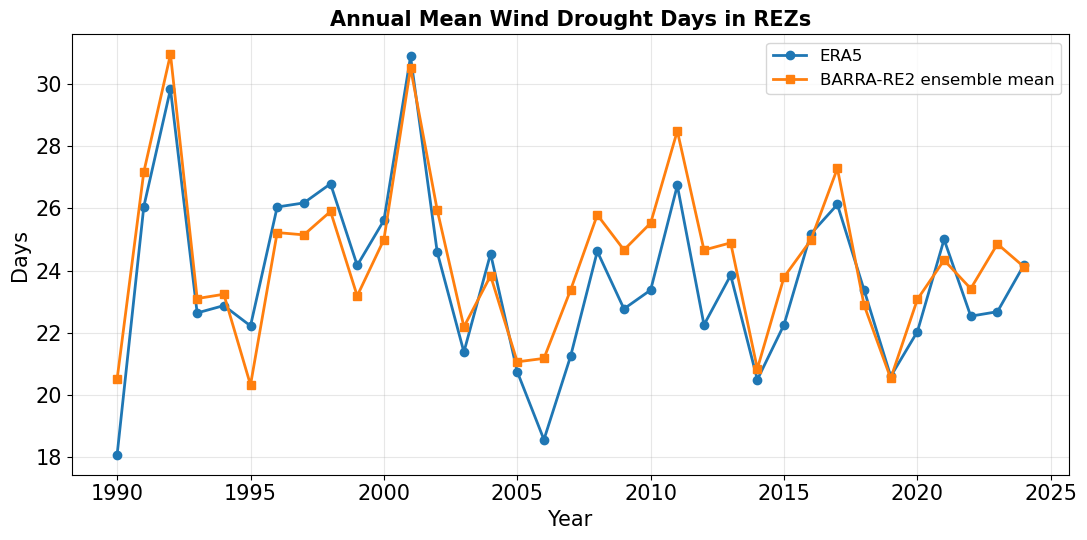

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_comparison/REZ_mean_annual_wind_drought_days_all_cells_ERA5_vs_BARRA_RE2.png


In [17]:
# =====================
# Plot 1: comparison using all REZ cells, zeros included
# This is the best direct comparison because it includes both frequency and spatial extent.
# =====================
plt.figure(figsize=(11, 5.5))

plt.plot(
    df_era5["year"],
    df_era5["mean_annual_drought_days_all_rez_cells"],
    marker="o",
    lw=2,
    label="ERA5"
)

plt.plot(
    df_barra["year"],
    df_barra["mean_annual_drought_days_all_rez_cells"],
    marker="s",
    lw=2,
    label="BARRA-RE2 ensemble mean"
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.xlabel("Year", fontsize=15)
plt.ylabel("Days", fontsize=15)
plt.title(
    "Annual Mean Wind Drought Days in REZs",
    fontsize=15,
    fontweight="bold"
)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

png_out = os.path.join(output_dir, "REZ_mean_annual_wind_drought_days_all_cells_ERA5_vs_BARRA_RE2.png")
plt.savefig(png_out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", png_out)


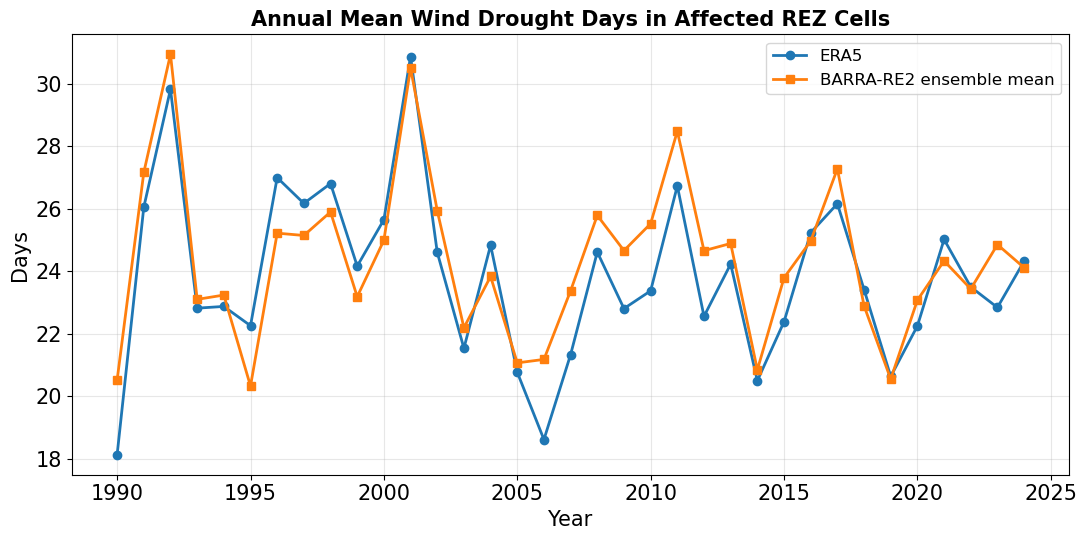

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_comparison/REZ_affected_cells_mean_annual_wind_drought_days_ERA5_vs_BARRA_RE2.png


In [18]:
# =====================
# Plot 2: comparison using only affected REZ cells
# This follows the metric used in the original notebook.
# =====================
plt.figure(figsize=(11, 5.5))

plt.plot(
    df_era5["year"],
    df_era5["mean_annual_drought_days_affected_cells"],
    marker="o",
    lw=2,
    label="ERA5"
)

plt.plot(
    df_barra["year"],
    df_barra["mean_annual_drought_days_affected_cells"],
    marker="s",
    lw=2,
    label="BARRA-RE2 ensemble mean"
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.xlabel("Year", fontsize=15)
plt.ylabel("Days", fontsize=15)
plt.title(
    "Annual Mean Wind Drought Days in Affected REZ Cells",
    fontsize=15,
    fontweight="bold"
)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

png_out = os.path.join(output_dir, "REZ_affected_cells_mean_annual_wind_drought_days_ERA5_vs_BARRA_RE2.png")
plt.savefig(png_out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", png_out)


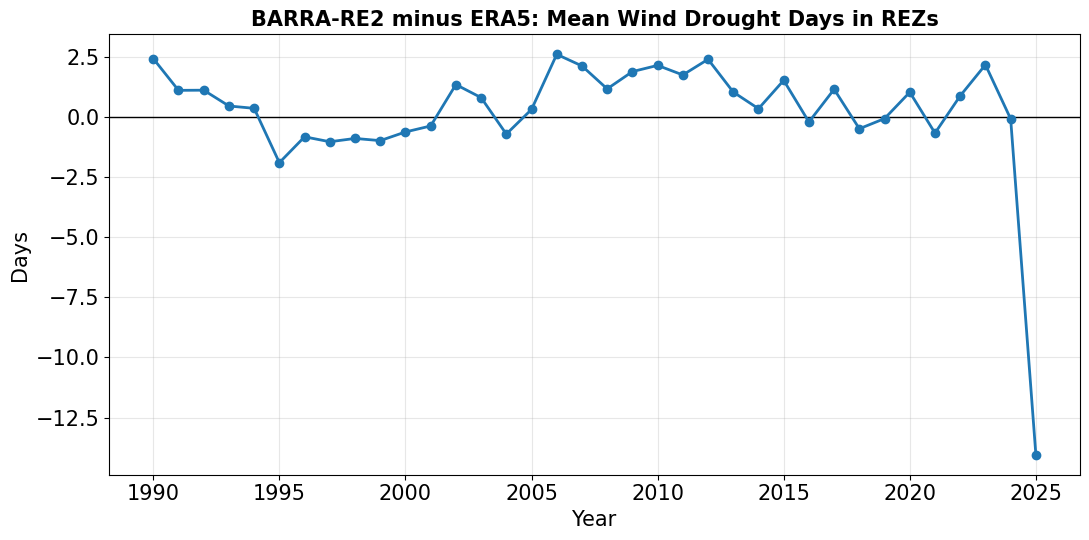

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_comparison/REZ_mean_annual_wind_drought_days_difference_BARRA_RE2_minus_ERA5.png


In [19]:
# =====================
# Plot 3: BARRA-RE2 minus ERA5 difference
# Positive = BARRA-RE2 has more mean annual drought days in REZs.
# Negative = BARRA-RE2 has fewer mean annual drought days in REZs.
# =====================
plt.figure(figsize=(11, 5.5))

plt.axhline(0, color="black", lw=1)

plt.plot(
    compare["year"],
    compare["difference_mean_all_rez_cells_BARRA_minus_ERA5"],
    marker="o",
    lw=2
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.xlabel("Year", fontsize=15)
plt.ylabel("Days", fontsize=15)
plt.title(
    "BARRA-RE2 minus ERA5: Mean Wind Drought Days in REZs",
    fontsize=15,
    fontweight="bold"
)
plt.grid(alpha=0.3)
plt.tight_layout()

png_out = os.path.join(output_dir, "REZ_mean_annual_wind_drought_days_difference_BARRA_RE2_minus_ERA5.png")
plt.savefig(png_out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", png_out)


In [20]:
# =====================
# Quick summary values
# =====================
summary = df_all.groupby("source").agg(
    mean_all_rez_cells_1990_2025=("mean_annual_drought_days_all_rez_cells", "mean"),
    mean_affected_rez_cells_1990_2025=("mean_annual_drought_days_affected_cells", "mean"),
    mean_affected_cell_fraction_1990_2025=("affected_cell_fraction", "mean"),
).reset_index()

summary_csv = os.path.join(output_dir, "REZ_annual_wind_drought_days_ERA5_vs_BARRA_RE2_summary.csv")
summary.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
summary


Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/rez_timeseries_comparison/REZ_annual_wind_drought_days_ERA5_vs_BARRA_RE2_summary.csv


,source,mean_all_rez_cells_1990_2025,mean_affected_rez_cells_1990_2025,mean_affected_cell_fraction_1990_2025
0,BARRA-RE2,23.955956,23.960384,0.999620
1,ERA5,23.750372,23.873921,0.994834
